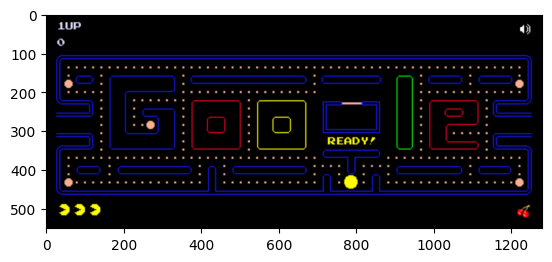

In [101]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

maze_bgr = cv.imread("./tests_folder/my_capture.png")
plt.imshow(maze_bgr[:,:,::-1])

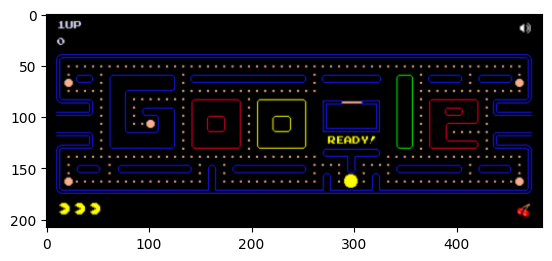

In [102]:
maze_reduced = cv.resize(maze_bgr, (484, 208), interpolation=cv.INTER_AREA)
plt.imshow(maze_reduced[:,:,::-1])

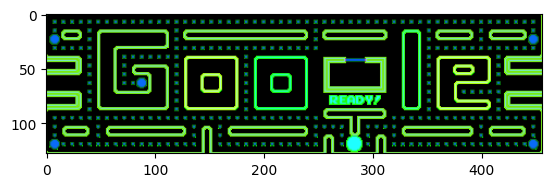

In [103]:
maze_croped = maze_reduced[44:172,14:470].copy() 
maze_hsv = cv.cvtColor(maze_croped, cv.COLOR_BGR2HSV)
plt.imshow(maze_hsv)

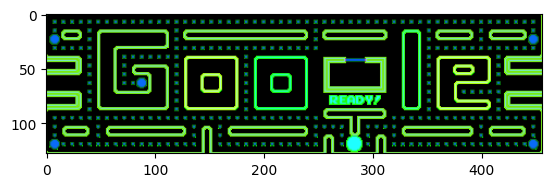

In [104]:
maze_rgb = cv.cvtColor(maze_croped, cv.COLOR_BGR2RGB) # maze_croped is bgr
maze_hsv_from_rgb = cv.cvtColor(maze_rgb, cv.COLOR_RGB2HSV)
plt.imshow(maze_hsv_from_rgb) # Conclusion pas de différence de résultat si on fait BGR=>HSV ou RGB=>HSV

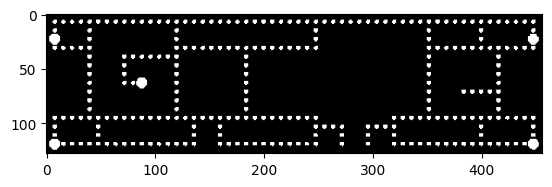

In [105]:
lower_yellow = np.uint8([0, 95, 5])  # 
upper_yellow = np.uint8([25, 255, 255])

pacgumsMask = cv.inRange(maze_hsv, lower_yellow, upper_yellow)
plt.imshow(pacgumsMask, cmap="gray")

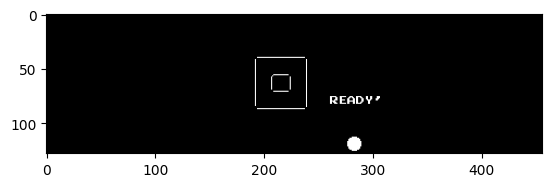

In [106]:
lower_yellow = np.uint8([30, 250, 150])  # 
upper_yellow = np.uint8([30, 255, 255])

pacmanMask = cv.inRange(maze_hsv, lower_yellow, upper_yellow)
plt.imshow(pacmanMask, cmap="gray")

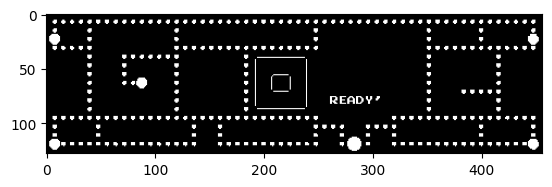

In [107]:
combinedMask = cv.bitwise_or(pacgumsMask, pacmanMask)
plt.imshow(combinedMask, cmap="gray")

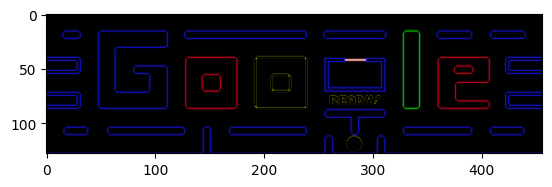

In [108]:
maskInversion = cv.bitwise_not(combinedMask)
pacgumRemoved = cv.bitwise_and(maze_croped, maze_croped, mask=maskInversion)
plt.imshow(pacgumRemoved[:,:,::-1])

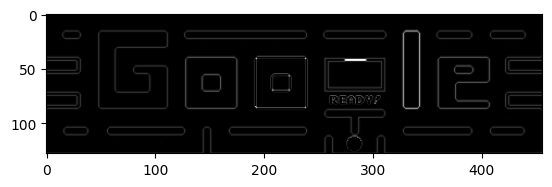

In [109]:
pacgumRemovedGray = cv.cvtColor(pacgumRemoved, cv.COLOR_BGR2GRAY)
plt.imshow(pacgumRemovedGray, cmap="gray")

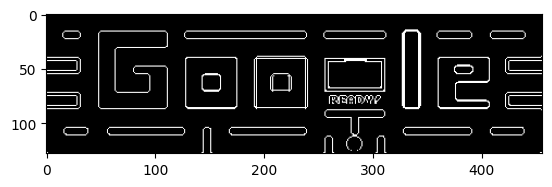

In [110]:
threshold, mythresh = cv.threshold(pacgumRemovedGray, 16, 255, cv.THRESH_BINARY)
plt.imshow(mythresh, cmap="gray")

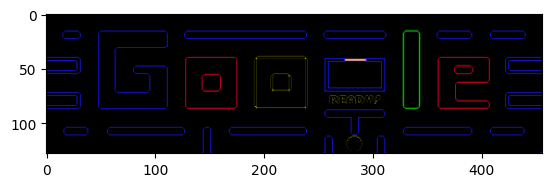

In [111]:
myMaze = cv.bitwise_and(pacgumRemoved, pacgumRemoved, mask=mythresh)
plt.imshow(myMaze[:,:,::-1])

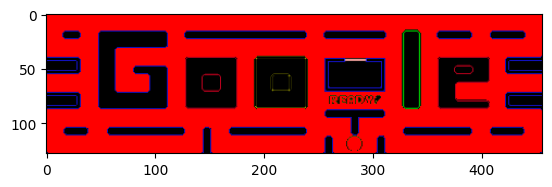

In [112]:
myMazeCopy = myMaze.copy()
cv.floodFill(myMazeCopy, None, (8,8), (0,0,255))
plt.imshow(myMazeCopy[:,:,::-1])

(128, 456)


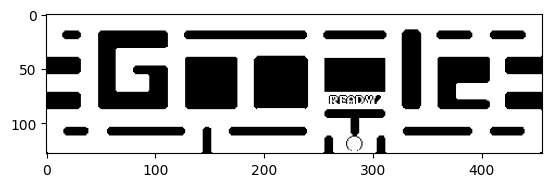

In [113]:
lower_yellow = np.uint8([0, 0, 25])
upper_yellow = np.uint8([0, 0, 255])

frameThreshPac = cv.inRange(myMazeCopy, lower_yellow, upper_yellow)
plt.imshow(frameThreshPac, cmap="gray")
print(frameThreshPac.shape)

In [114]:
REDUCTION_KERNEL = 8
WHITE_THRESHOLD_PERC = 30
WHITE_THRESHOLD = REDUCTION_KERNEL**2 * WHITE_THRESHOLD_PERC // 100
print(frameThreshPac.shape[0] // REDUCTION_KERNEL, frameThreshPac.shape[1] // REDUCTION_KERNEL)
compressedMat = np.zeros((frameThreshPac.shape[0] // REDUCTION_KERNEL, frameThreshPac.shape[1] // REDUCTION_KERNEL), dtype=np.int8)


16 57


In [115]:
#vérifier le nombre de pixel blancs dans un carré
# associer un intervalle de l'image d'origine à un indexe de l'image compressée
# SOIT range(0, frameThreshPac.shape[1], REDUCTION_KERNEL)
# SOIT range(frameThreshPac.shape[1] // REDUCTION_KERNEL)
# ALGORITHM : Write compressed matrix

for X in range(0, frameThreshPac.shape[0], REDUCTION_KERNEL):


    for Y in range(0, frameThreshPac.shape[1], REDUCTION_KERNEL):
        currentKernel = frameThreshPac[X:X+(REDUCTION_KERNEL-1),Y:Y+(REDUCTION_KERNEL-1)]
        if np.count_nonzero(currentKernel == 255) >= WHITE_THRESHOLD: # si au moins 30% des pixels sont blancs, passer noir
            compressedMat[X//REDUCTION_KERNEL, Y//REDUCTION_KERNEL] = 1
        else:
            compressedMat[X//REDUCTION_KERNEL, Y//REDUCTION_KERNEL] = 0



In [116]:

for X in range(frameThreshPac.shape[0] // REDUCTION_KERNEL): 
    for Y in range(frameThreshPac.shape[1] // REDUCTION_KERNEL):
        print("{:>2}".format(compressedMat[X, Y]), end='')
    print()



 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1
 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 0 0 1 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0
 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1

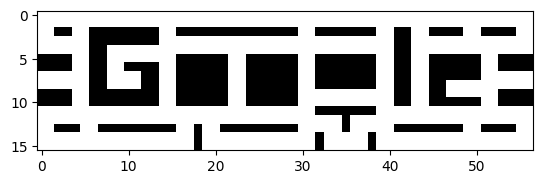

In [117]:
plt.imshow(compressedMat, cmap="gray")

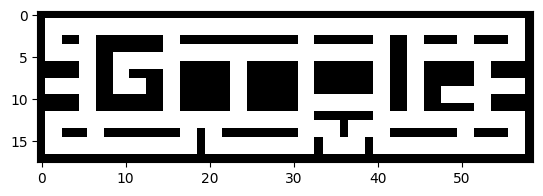

In [118]:
row, col = compressedMat.shape[:2]
bottom = compressedMat[row-2:row, 0:col]
mean = cv.mean(bottom)[0]

borderSize = 1
compressedMatBlackBorder = cv.copyMakeBorder(
    compressedMat,
    top=borderSize,
    bottom=borderSize,
    left=borderSize,
    right=borderSize,
    borderType=cv.BORDER_CONSTANT,
    value=0
)

plt.imshow(compressedMatBlackBorder, cmap="gray")

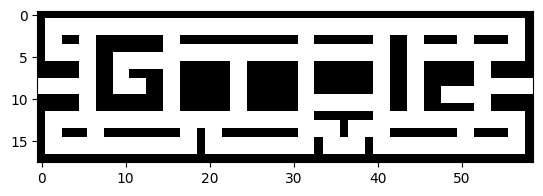

In [119]:
compressedMatBlackBorder[compressedMatBlackBorder.shape[0]//2, 0] = 1
compressedMatBlackBorder[compressedMatBlackBorder.shape[0]//2 - 1, 0] = 1
compressedMatBlackBorder[compressedMatBlackBorder.shape[0]//2, compressedMatBlackBorder.shape[1] - 1] = 1
compressedMatBlackBorder[compressedMatBlackBorder.shape[0]//2 - 1, compressedMatBlackBorder.shape[1] - 1] = 1

plt.imshow(compressedMatBlackBorder, cmap="gray")

In [135]:
print(type(compressedMatBlackBorder))
print(compressedMatBlackBorder.shape)

<class 'numpy.ndarray'>
(18, 59)


In [120]:
print(frameThreshPac.shape[0]*frameThreshPac.shape[1] / compressedMatBlackBorder.shape[0]*compressedMatBlackBorder.shape[1])

191317.3333333333


Conclusion : La dimension du problème a été réduite par près de 200 000 fois

In [121]:
available_positions = 0
for i in range(compressedMatBlackBorder.shape[0]-1):
    for j in range(compressedMatBlackBorder.shape[1]-1):
        if (compressedMatBlackBorder[i,j] == 1):
            if ((compressedMatBlackBorder[i][j+1] == 1) and (compressedMatBlackBorder[i+1][j] == 1) and (compressedMatBlackBorder[i+1][j+1] == 1)):
                available_positions += 1
print(available_positions)

320


In [ ]:
available_positions**5 # car 5 personnages

3355443200000

Malgré cette réduction de dimension significative, la dimension du problème reste gigantesque :
Il y a de l'ordre de 3 355 milliards d'états possibles même avec la matrice réduite (positions relatives des cinq personnages (pacman + 4 fantômes) sur les cases du labyrinthe accessibles). This is not computationnaly tractable. De plus, DP pas applicable car on a dit que le problème du Pacman était non-stationnaire (en raison des mvt pseudo aléatoires des fantômes). Sachant qu'à titre de comparaison, la limite d'un fichier excel est de l'ordre de un peu plus d'1 million de lignes

In [123]:
np.count_nonzero(compressedMatBlackBorder == 1)

np.int64(608)

In [124]:
cv.imwrite("./tests_folder/binarizedMazeCompressed.png", compressedMatBlackBorder)

True

Prochaine étape: passer de la détection du Pacman réduite pour l'associer aux indices correspondants dans la matrice compressée

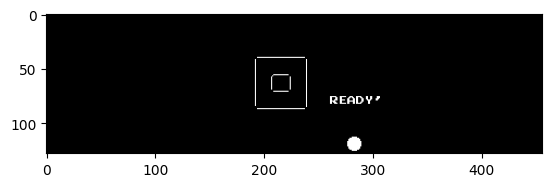

In [125]:
plt.imshow(pacmanMask, cmap="gray")

32 32


'\npacmanSquared = maze_croped.copy()\ncv.rectangle(pacmanSquared,(x,y),(x+w,y+h),(0, 0, 255),1)\npacmanSquaredRGB = cv.cvtColor(pacmanSquared, cv.COLOR_BGR2RGB)\nplt.imshow(pacmanSquaredRGB)\n'

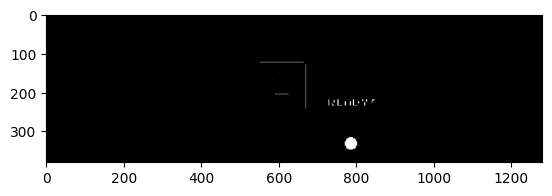

In [133]:
full_size_cropped = maze_bgr[100:480,:]

pureYellow = (255, 255, 0)
testImageRGB = cv.cvtColor(full_size_cropped, cv.COLOR_BGR2RGB)

mask = np.zeros(testImageRGB.shape[:])
mask[:] = (255, 255, 0) # pure yellow, color of pacman
result = np.where(np.all(testImageRGB == mask, axis=2), 255, 0).astype(np.uint8)

plt.imshow(result, cmap="gray")

cnts,hierarchy = cv.findContours(result,cv.RETR_LIST,cv.CHAIN_APPROX_SIMPLE)
cnt = sorted(cnts, key=cv.contourArea)
x,y,w,h = cv.boundingRect(cnt[-1])
print(w,h)
"""
pacmanSquared = maze_croped.copy()
cv.rectangle(pacmanSquared,(x,y),(x+w,y+h),(0, 0, 255),1)
pacmanSquaredRGB = cv.cvtColor(pacmanSquared, cv.COLOR_BGR2RGB)
plt.imshow(pacmanSquaredRGB)
"""

In [127]:
transcodingDict = {
    "0-8": 0,
    "8-16": 1,
    "16-24": 2
}
# clé : intervalle (str)
# valeur : indice correspondant dans la nouvelle mat

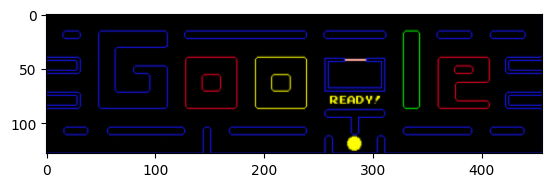

In [128]:
maskInversion = cv.bitwise_not(pacgumsMask)
pacgumRemoved = cv.bitwise_and(maze_rgb, maze_rgb, mask=maskInversion)
plt.imshow(pacgumRemoved)

In [129]:
def get_limits(color):
    c = np.uint8([[color]])  # BGR values
    hsvC = cv.cvtColor(c, cv.COLOR_BGR2HSV)

    hue = hsvC[0][0][0]  # Get the hue value

    # Handle red hue wrap-around
    if hue >= 165:  # Upper limit for divided red hue
        lowerLimit = np.array([hue - 10, 100, 100], dtype=np.uint8)
        upperLimit = np.array([180, 255, 255], dtype=np.uint8)
    elif hue <= 15:  # Lower limit for divided red hue
        lowerLimit = np.array([0, 100, 100], dtype=np.uint8)
        upperLimit = np.array([hue + 10, 255, 255], dtype=np.uint8)
    else:
        lowerLimit = np.array([hue - 10, 100, 100], dtype=np.uint8)
        upperLimit = np.array([hue + 10, 255, 255], dtype=np.uint8)

    return lowerLimit, upperLimit

In [130]:
get_limits((29,252,53))

(array([ 47, 100, 100], dtype=uint8), array([ 67, 255, 255], dtype=uint8))